# Load the trajectories 

In [17]:
import pandas as pd
import numpy as np

def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def load_csv(filepath):
    # Load CSV and handle potential whitespace/formatting issues
    df = pd.read_csv(filepath)
    
    # Clean column names (remove leading/trailing spaces)
    df.columns = df.columns.str.strip()
    
    # Convert all numeric columns to proper numeric types
    numeric_columns = ['timestamp_real', 'timestamp_est', 'real_x', 'real_y', 'real_theta', 
                      'est_x', 'est_y', 'est_theta', 'cov_x', 'cov_y', 'cov_theta']
    
    for col in numeric_columns:
        if col in df.columns:
            # Convert to string first, strip whitespace, then convert to numeric
            # This handles cases where values might have spaces or be mixed types
            df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')
    
    # Check for any NaN values after conversion
    nan_counts = df[numeric_columns].isnull().sum()
    if nan_counts.sum() > 0:
        print(f"Warning: Found {nan_counts.sum()} NaN values, dropping incomplete rows")
        # Drop rows with any NaN values in numeric columns
        df = df.dropna(subset=numeric_columns)
        print(f"Remaining rows after cleanup: {len(df)}")
    
    # Subtract initial time to normalize timestamps
    df['timestamp_normalized'] = df['timestamp_real'] - df['timestamp_real'].iloc[0]

    # Compute positional error
    df['positional_error'] = np.sqrt((df['est_x'] - df['real_x'])**2 + (df['est_y'] - df['real_y'])**2)

    # Compute angular error
    df['angular_error'] = np.abs(wrap_to_pi(df['est_theta'] - df['real_theta']))

    # Convert to degrees
    df['angular_error_deg'] = np.degrees(df['angular_error'])

    covariances = []

    for i, row in df.iterrows():
        cov_x = row['cov_x']
        cov_y = row['cov_y']
        
        # Construct 2x2 covariance matrix assuming zero correlation
        cov_matrix = np.array([[cov_x, 0],
                            [0, cov_y]])
        covariances.append(cov_matrix)

    # Convert list to numpy array (shape: [num_points, 2, 2])
    covariances = np.array(covariances)
    return df



# Load the trajectories
df_A = load_csv('/home/biltes/ros_ws/src/robot_worlds/trials/Nave_A_MM_2025-07-24_19-01.csv')
#df_B = load_csv('/home/joao/dev/PF_graphs/MM_FAISS/20000_particles/Area_B_loop/Area_B_loop_MM_FAISS_2025-07-18_21-48.csv')
#df_C = load_csv('/home/joao/dev/PF_graphs/MM_FAISS/20000_particles/Area_C_loop/Area_C_loop_MM_FAISS_2025-07-19_10-02.csv')
#df_ACA = load_csv('/home/joao/dev/PF_graphs/MM_FAISS/20000_particles/A_C_A/A_C_A_MM_FAISS_2025-07-17_23-03.csv')
#df_BCA = load_csv('/home/joao/dev/PF_graphs/MM_FAISS/20000_particles/B_C_A/B_C_A_MM_FAISS_2025-07-18_21-51.csv')

Remaining rows after cleanup: 788


# Positional and angular errors

Area A Loop — Stable convergence time: 14.52s
Area A Loop — Mean positional error after convergence: 0.984 m
Area A Loop — Mean angular error after convergence: 3.34°

Plot saved to /home/biltes/PF_graphs/Area_A_errors.png
Plot saved to /home/biltes/PF_graphs/Area_A_errors.png


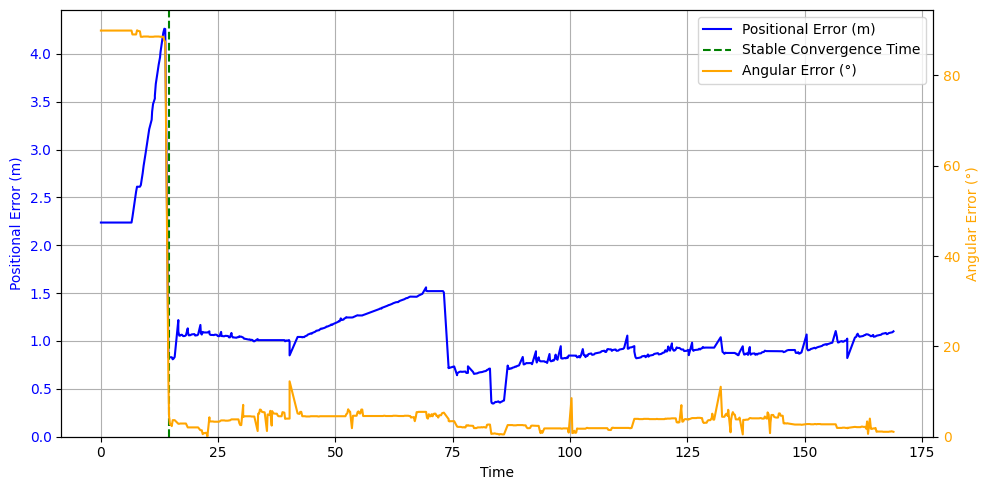

Area A Loop          & 14.52 & 0.98 & 3.34 \\
Area B Loop          & - & - & - \\
Area C Loop          & - & - & - \\
A to C to A          & - & - & - \\
B to C to A          & - & - & - \\


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def get_stable_convergence(df):
    convergence_pos_threshold = 1
    convergence_ang_threshold_deg = 10

    divergence_pos_threshold = 3
    divergence_ang_threshold_deg = 30

    convergence_time = None
    mean_pos_error = -1
    mean_ang_error = -1

    has_converged = False

    for i in range(len(df)):
        row = df.iloc[i]

        pos_error = row['positional_error']
        ang_error = row['angular_error_deg']
        time = row['timestamp_normalized']

        # Check convergence condition
        if (pos_error < convergence_pos_threshold) and (ang_error < convergence_ang_threshold_deg):
            if not has_converged:
                # Start a convergence window
                convergence_time = time
                has_converged = True
        # If already converged but now diverged again, invalidate convergence
        elif (pos_error > divergence_pos_threshold) or (ang_error > divergence_ang_threshold_deg):
            if has_converged:
                print(f"Convergence invalidated at {time:.2f}s due to divergence.")
            has_converged = False
            convergence_time = None

    # If we ended in a converged state, compute mean errors from that point onward
    if has_converged and convergence_time is not None:
        post_conv_df = df[df['timestamp_normalized'] >= convergence_time]
        mean_pos_error = post_conv_df['positional_error'].mean()
        mean_ang_error = post_conv_df['angular_error_deg'].mean()
        return convergence_time, mean_pos_error, mean_ang_error
    else:
        print("No stable convergence detected.")
        return -1, -1, -1

table_values = {}
def plot_errors(df, title='', save_path=None):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot positional error
    ax1.plot(df['timestamp_normalized'], df['positional_error'], label='Positional Error (m)', color='blue')
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Positional Error (m)", color='blue')
    ax1.set_ylim(bottom=0)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid()

    # Plot angular error
    ax2 = ax1.twinx()
    ax2.plot(df['timestamp_normalized'], df['angular_error_deg'], label='Angular Error (°)', color='orange')
    ax2.set_ylabel("Angular Error (°)", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(bottom=0)

    # Use stable convergence function
    convergence_time, mean_pos_error, mean_ang_error = get_stable_convergence(df)

    if convergence_time != -1:
        ax1.axvline(convergence_time, color='green', linestyle='--', label='Stable Convergence Time')

        table_values[title] = (convergence_time, mean_pos_error, mean_ang_error)

        print(f"{title} — Stable convergence time: {convergence_time:.2f}s")
        print(f"{title} — Mean positional error after convergence: {mean_pos_error:.3f} m")
        print(f"{title} — Mean angular error after convergence: {mean_ang_error:.2f}°\n")
    else:
        print(f"{title} — No stable convergence detected.\n")

    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")

    plt.show()

# Call the function with each dataset
plot_errors(df_A, title="Area A Loop", save_path='/home/biltes/PF_graphs/Area_A_errors.png')
#plot_errors(df_B, title="Area B Loop", save_path='/home/joao/dev/PF_graphs/Area_B_errors.png')
#plot_errors(df_C, title="Area C Loop", save_path='/home/joao/dev/PF_graphs/Area_C_errors.png')
#plot_errors(df_ACA, title="A to C to A", save_path='/home/joao/dev/PF_graphs/ACA_errors.png')
#plot_errors(df_BCA, title="B to C to A", save_path='/home/joao/dev/PF_graphs/BCA_errors.png')

# Print formatted results
def format_entry(name):
    if name in table_values:
        conv, pos, ang = table_values[name]
        return f"{name:<20} & {conv:.2f} & {pos:.2f} & {ang:.2f} \\\\"
    else:
        return f"{name:<20} & - & - & - \\\\"

print(format_entry("Area A Loop"))
print(format_entry("Area B Loop"))
print(format_entry("Area C Loop"))
print(format_entry("A to C to A"))
print(format_entry("B to C to A"))


# Plot the trajectories

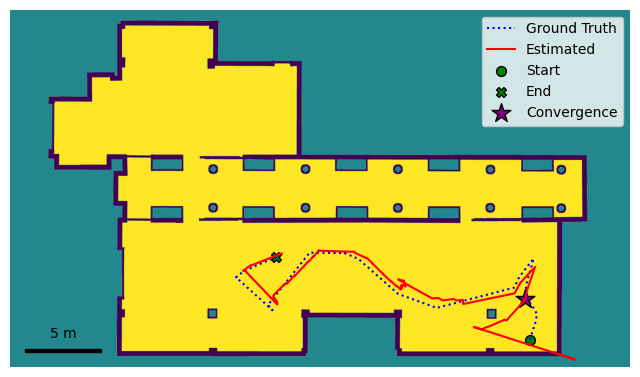

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches

def plot_both_trajectories(df, name = ''):
        # Load the map image - using the available map from the workspace
        map_img = mpimg.imread('/home/biltes/ros_ws/src/robot_worlds/maps/iilab_biltes/iilab_biltes.pgm')

        height, width = map_img.shape[:2]

        xmin = -36.1
        ymin = -0.8
        xmax = xmin + width * 0.0237
        ymax = ymin + height * 0.0237

        extent = [xmin, xmax, ymin, ymax]8. Nave_A_MM_2025-07-23_23-30.csv (modified: 2025-07-23 22:31:47)
  39. Nave_A_MM_2025-07-23_23-24.csv (modified: 2025-07-23 22:26:34)
  40. Nave_A_MM_2025-07-23_23-11.csv (modified: 2025-07-23 22:15:00)
  41. Nave_A_MM_2025-07-23_23-09.csv (modified: 2025-07-23 22:10:47)
  42. Nave_A_MM_2025-07-23_22-19.csv (modified: 2025-07-23 21:29:11)
  43. Nave_A_MM_2025-07-23_22-15.csv (modified: 2025-07-23 21:16:52)
  44. Nave_A_MM_2025-07-23_21-55.csv (modified: 2025-07-23 21:00:20)
  45. Nave_A_MM_2025-07-23_21-40.csv (modified: 2025-07-23 20:43:10)
  46. Nave_A_MM_2025-07-23_21-39.csv (modified: 2025-07-23 20:39:51)
  47. Nave_A_MM_2025-07-23_21-23.csv (modified: 2025-07-23 20:24:57)
  48. Nave_A_MM_2025-07-23_21-22.csv (modified: 2025-07-23 20:22:59)
  49. Nave_A_MM_2025-07-23_20-10.csv (modified: 2025-07-23 19:13:48)
🎯 Using most recent file: Nave_A_MM_2025-07-24_19-01.csv
✅ Successfully loaded Nave_A_MM_2025-07-24_19-01.csv with 789 rows
📊 CSV columns: ['timestamp_real', ' timestamp_est', ' real_x', ' real_y', ' real_theta', ' est_x', ' est_y', ' est_theta', ' cov_x', ' cov_y', ' cov_theta']
📏 Data shape: (789, 11)
Traceback (most recent call last):
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/ops/array_ops.py", line 218, in _na_arithmetic_op
    result = func(left, right)
             ^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/computation/expressions.py", line 242, in evaluate
    return _evaluate(op, op_str, a, b)  # type: ignore[misc]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/computation/expressions.py", line 73, in _evaluate_standard
    return op(a, b)
           ^^^^^^^^
TypeError: unsupported operand type(s) for -: 'float' and 'str'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/biltes/ros_ws/src/robot_worlds/trials/make_graphs.py", line 110, in <module>
    df['angular_error'] = np.abs(wrap_to_pi(df['est_theta'] - df['real_theta']))
                                            ~~~~~~~~~~~~~~~~^~~~~~~~~~~~~~~~~~
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/ops/common.py", line 76, in new_method
    return method(self, other)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py", line 194, in __sub__
    return self._arith_method(other, operator.sub)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/series.py", line 6146, in _arith_method
    return base.IndexOpsMixin._arith_method(self, other, op)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/base.py", line 1391, in _arith_method
    result = ops.arithmetic_op(lvalues, rvalues, op)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/ops/array_ops.py", line 283, in arithmetic_op
    res_values = _na_arithmetic_op(left, right, op)  # type: ignore[arg-type]
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/ops/array_ops.py", line 227, in _na_arithmetic_op
    result = _masked_arith_op(left, right, op)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/biltes/ros_ws/src/.venv/lib/python3.12/site-packages/pandas/core/ops/array_ops.py", line 163, in _masked_arith_op
    result[mask] = op(xrav[mask], yrav[mask])
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: unsupported operand type(s) for -: 'float' and 'str'

        plt.figure(figsize=(8,8))

        # Show the map image
        plt.imshow(map_img, extent=extent, origin='upper')  # origin='upper' if needed

        # Plot trajectories on top
        plt.plot(df[' real_x'], df[' real_y'], label='Ground Truth', color='blue', linestyle=':')
        plt.plot(df[' est_x'], df[' est_y'], label='Estimated', color='red')

        # Start point (circle)
        plt.scatter(df[' real_x'].iloc[0], df[' real_y'].iloc[0], color='green', marker='o', edgecolors='black', s=50, label='Start')

        # End point (X)
        plt.scatter(df[' real_x'].iloc[-1], df[' real_y'].iloc[-1], color='green', marker='X', edgecolors='black', s=50, label='End')

        convergence_time, _, _ = get_stable_convergence(df)
        if convergence_time != -1:
                index = df['timestamp_normalized'].sub(convergence_time).abs().idxmin()
                plt.scatter(df[' est_x'].iloc[index], df[' est_y'].iloc[index],
                color='purple', marker='*', edgecolors='black', s=200, label='Convergence')
                
        plt.xlabel('X (m)')
        plt.ylabel('Y (m)')
        plt.legend()
        plt.axis('off')
        # plt.grid()  # Don't call grid or comment out to disable grid

        # Add scale bar
        ax = plt.gca()

        # Parameters for the scale bar
        scalebar_length = 5  # length in meters
        scalebar_height = 0.2  # thickness of the bar
        x_start = extent[0] + 1  # 1 meter from left
        y_start = extent[2] + 1  # 1 meter from bottom

        # Draw a black rectangle as scale bar
        scale_bar = patches.Rectangle((x_start, y_start), scalebar_length, scalebar_height, edgecolor='black', facecolor='black')
        ax.add_patch(scale_bar)

        # Add text above scale bar
        ax.text(x_start + scalebar_length/2, y_start + scalebar_height + 0.5, f'{scalebar_length} m',
                ha='center', va='bottom', fontsize=10, color='black')

        plt.show()

plot_both_trajectories(df_A, "Area A loop")
#plot_both_trajectories(df_B, "Area A loop")
#plot_both_trajectories(df_C, "Area A loop")
#plot_both_trajectories(df_ACA, "Area A loop")
#plot_both_trajectories(df_BCA, "Area A loop")

## Plot the ground truths


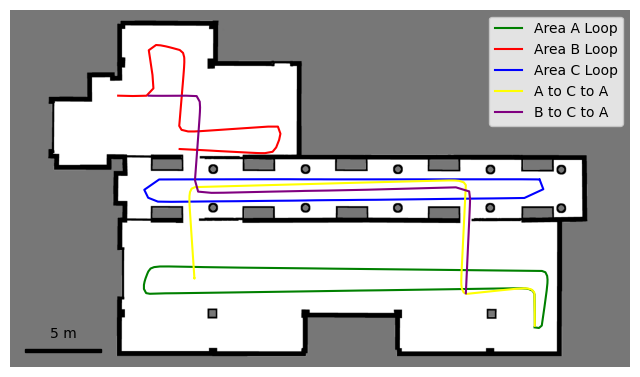

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import pandas as pd

# Load the map image - using the available map from the workspace
map_img = mpimg.imread('/home/biltes/ros_ws/src/robot_worlds/maps/iilab_biltes/iilab_biltes.pgm')

# Load the trajectories - only using available data for now
df_A = pd.read_csv('/home/joao/dev/PF_graphs/Area_A_loop/Area_A_loop_MM_FAISS_2025-07-17_22-58.csv')
# df_B = pd.read_csv('/home/joao/dev/PF_graphs/Area_B_loop/Area_B_loop_MM_FAISS_2025-07-18_21-48.csv')
# df_C = pd.read_csv('/home/joao/dev/PF_graphs/Area_C_loop/Area_C_loop_MM_FAISS_2025-07-19_10-02.csv')
# df_ACA = pd.read_csv('/home/joao/dev/PF_graphs/A_C_A/A_C_A_MM_FAISS_2025-07-17_23-03.csv')
# df_BCA = pd.read_csv('/home/joao/dev/PF_graphs/B_C_A/B_C_A_MM_FAISS_2025-07-18_21-51.csv')

height, width = map_img.shape[:2]

xmin = -36.1
ymin = -0.8
xmax = xmin + width * 0.0237
ymax = ymin + height * 0.0237

extent = [xmin, xmax, ymin, ymax]

plt.figure(figsize=(8,8))

# Show the map image
plt.imshow(map_img, extent=extent, origin='upper')  # origin='upper' if needed

# Plot trajectories on top with start/end points
def plot_trajectory_with_markers(df, label, color):
    x = df[' real_x']
    y = df[' real_y']
    plt.plot(x, y, label=label, color=color)

    # Start point (circle)
    #plt.scatter(x.iloc[0], y.iloc[0], color=color, marker='o', edgecolors='black', s=50)
    # End point (X)
    #plt.scatter(x.iloc[-1], y.iloc[-1], color=color, marker='X', edgecolors='black', s=50)

# Plot each trajectory - only the available one for now
plot_trajectory_with_markers(df_A, 'Area A Loop', 'green')
# plot_trajectory_with_markers(df_B, 'Area B Loop', 'red')
# plot_trajectory_with_markers(df_C, 'Area C Loop', 'blue')
# plot_trajectory_with_markers(df_ACA, 'A to C to A', 'yellow')
# plot_trajectory_with_markers(df_BCA, 'B to C to A', 'purple')


plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.legend()
plt.axis('off')
# plt.grid()  # Don't call grid or comment out to disable grid

# Add scale bar
ax = plt.gca()

# Parameters for the scale bar
scalebar_length = 5  # length in meters
scalebar_height = 0.2  # thickness of the bar
x_start = extent[0] + 1  # 1 meter from left
y_start = extent[2] + 1  # 1 meter from bottom

# Draw a black rectangle as scale bar
scale_bar = patches.Rectangle((x_start, y_start), scalebar_length, scalebar_height, edgecolor='black', facecolor='black')
ax.add_patch(scale_bar)

# Add text above scale bar
ax.text(x_start + scalebar_length/2, y_start + scalebar_height + 0.5, f'{scalebar_length} m',
        ha='center', va='bottom', fontsize=10, color='black')

plt.show()

## Per trajectory stats

In [19]:
import numpy as np
import pandas as pd

def compute_trajectory_stats(df, name):
    # Clean up column names
    df = df.rename(columns=lambda x: x.strip())  # Remove any leading/trailing spaces
    x = df['real_x'].values
    y = df['real_y'].values

    # Compute distances between consecutive points
    distances = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    total_length = np.sum(distances)  # in meters

    # Duration (if 'timestamp' column exists)
    if 'timestamp_real' in df.columns:
        timestamps = df['timestamp_real']
        duration = (timestamps.iloc[-1] - timestamps.iloc[0]) 
    else:
        duration = None  # or raise a warning/log
    print(f"{name} Length: {total_length:.2f} meters")
    if duration_A:
        print(f"{name} Duration: {duration:.2f} seconds")


    return total_length, duration

length_A, duration_A = compute_trajectory_stats(df_A, "Area A loop")
length_B, duration_B = compute_trajectory_stats(df_B, "Area B loop")
length_C, duration_C = compute_trajectory_stats(df_C, "Area C loop")
length_ACA, duration_ACA = compute_trajectory_stats(df_ACA, "Area A_C_A loop")
length_BCA, duration_BCA = compute_trajectory_stats(df_BCA, "Area A loop")


Area A loop Length: 59.49 meters
Area A loop Duration: 119.08 seconds
Area B loop Length: 26.89 meters
Area B loop Duration: 73.54 seconds
Area C loop Length: 53.46 meters
Area C loop Duration: 115.00 seconds
Area A_C_A loop Length: 38.13 meters
Area A_C_A loop Duration: 86.48 seconds
Area A loop Length: 34.03 meters
Area A loop Duration: 72.03 seconds


## 10 trial average

 — Stable convergence time: 17.70s
 — Mean positional error after convergence: 0.989 m
 — Mean angular error after convergence: 2.83°



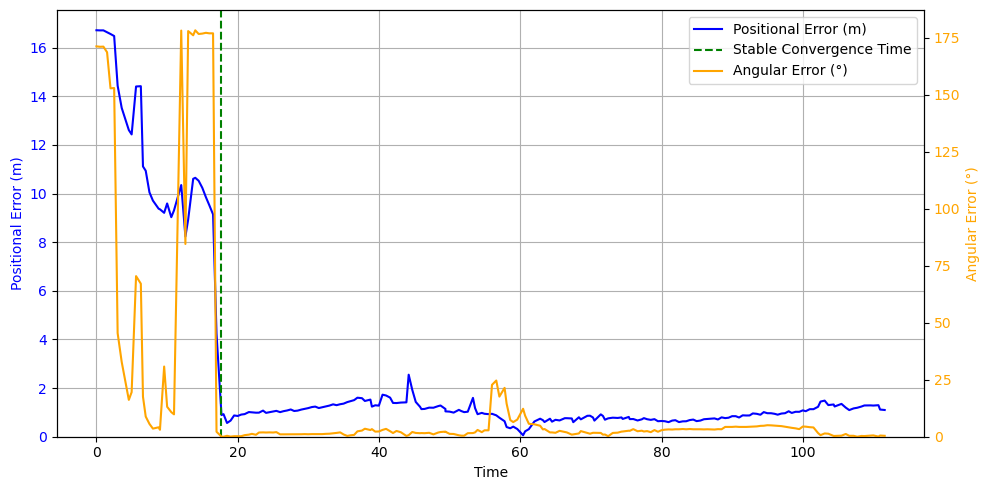

Convergence invalidated at 45.99s due to divergence.
Convergence invalidated at 45.99s due to divergence.
 — Stable convergence time: 51.98s
 — Mean positional error after convergence: 0.891 m
 — Mean angular error after convergence: 3.72°



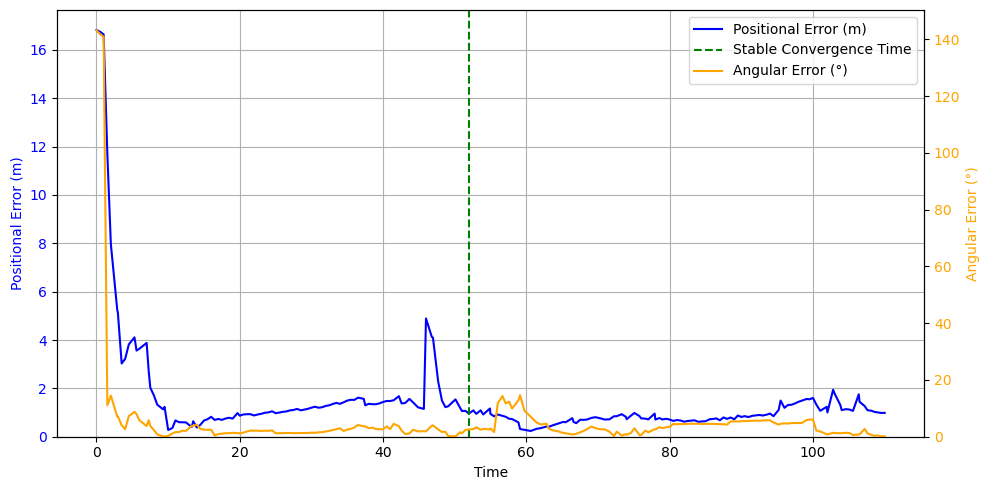

 — Stable convergence time: 14.69s
 — Mean positional error after convergence: 1.001 m
 — Mean angular error after convergence: 2.85°



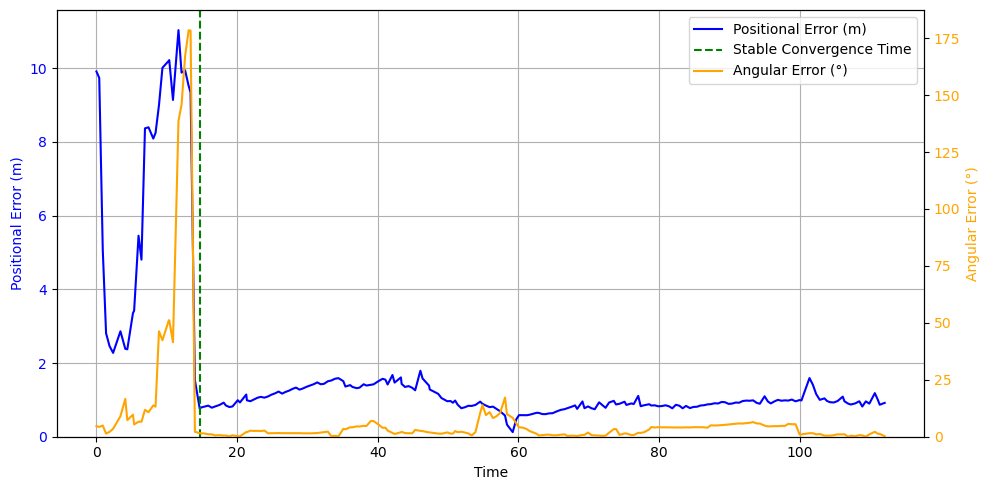

Convergence invalidated at 44.28s due to divergence.
Convergence invalidated at 44.28s due to divergence.
 — Stable convergence time: 56.67s
 — Mean positional error after convergence: 1.096 m
 — Mean angular error after convergence: 4.04°



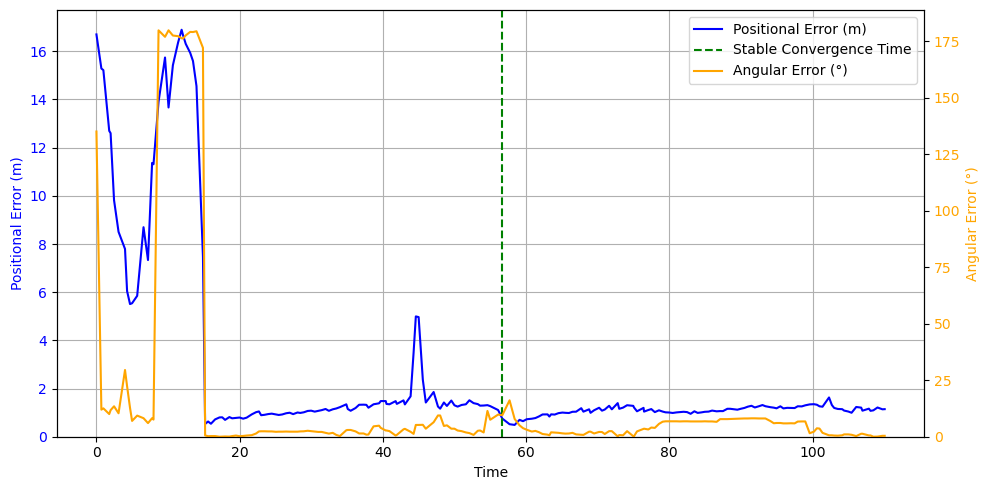

 — Stable convergence time: 15.51s
 — Mean positional error after convergence: 1.157 m
 — Mean angular error after convergence: 2.73°



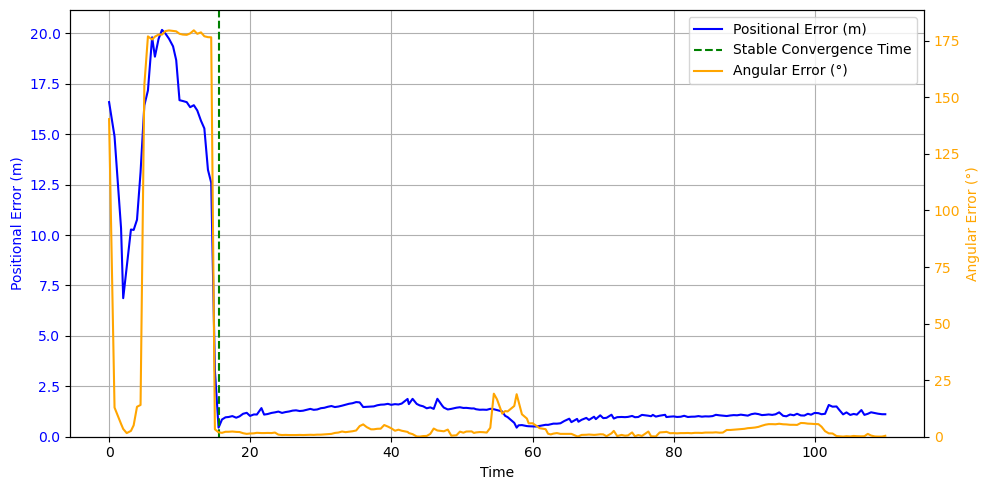

Convergence invalidated at 45.50s due to divergence.
Convergence invalidated at 45.50s due to divergence.
 — Stable convergence time: 59.48s
 — Mean positional error after convergence: 0.910 m
 — Mean angular error after convergence: 1.89°



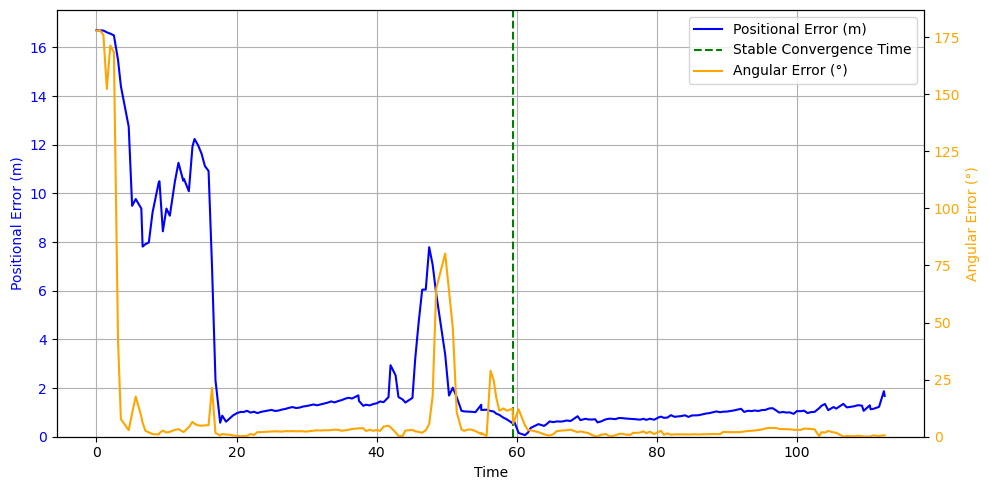

Convergence invalidated at 41.60s due to divergence.
Convergence invalidated at 41.60s due to divergence.
 — Stable convergence time: 54.99s
 — Mean positional error after convergence: 0.960 m
 — Mean angular error after convergence: 3.16°



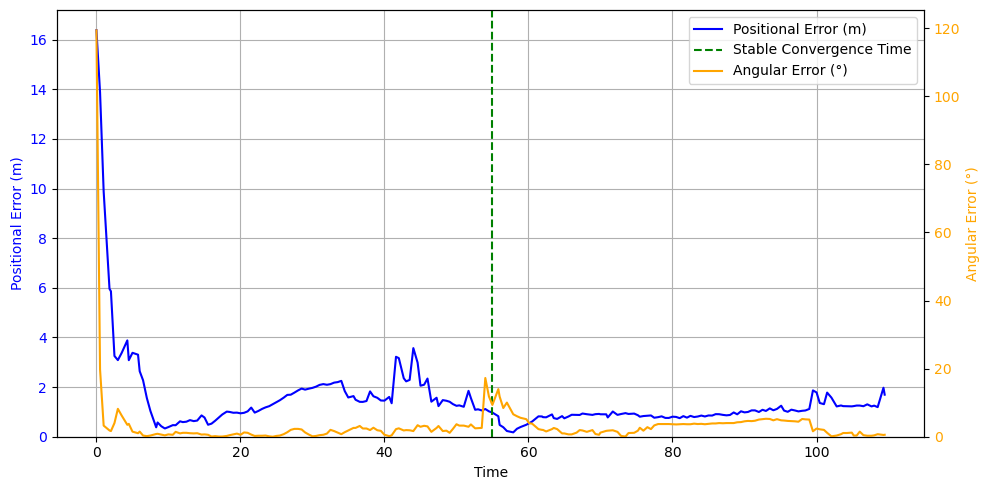

Convergence invalidated at 45.03s due to divergence.
Convergence invalidated at 45.03s due to divergence.
 — Stable convergence time: 50.03s
 — Mean positional error after convergence: 0.719 m
 — Mean angular error after convergence: 2.43°



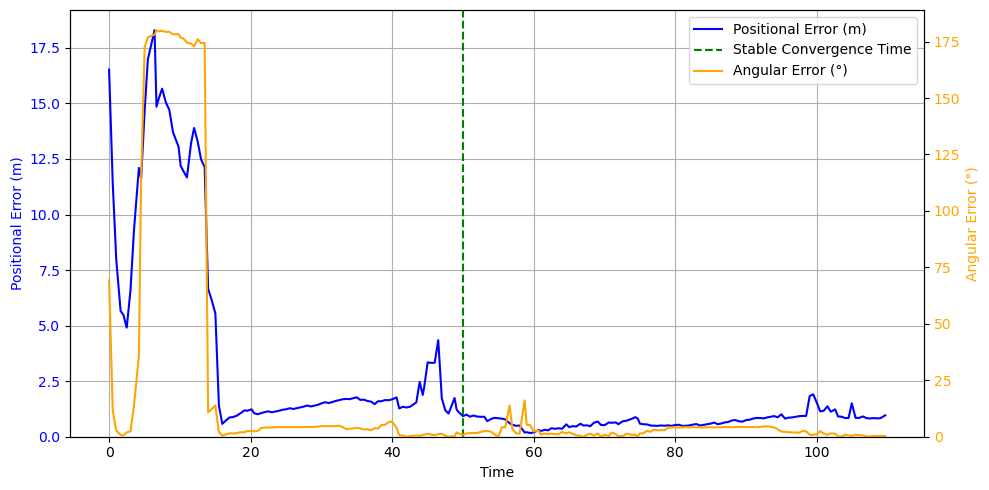

 — Stable convergence time: 14.69s
 — Mean positional error after convergence: 1.302 m
 — Mean angular error after convergence: 3.28°



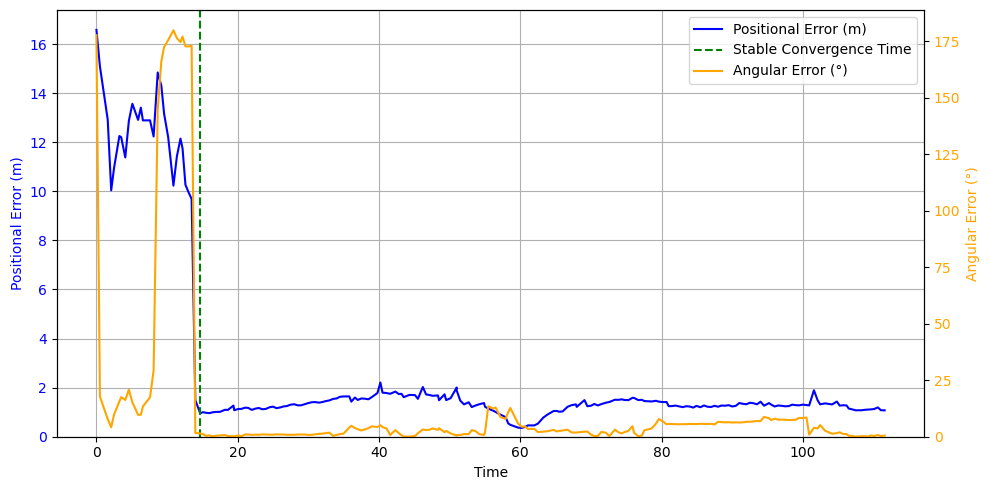

Convergence invalidated at 45.40s due to divergence.
Convergence invalidated at 45.40s due to divergence.
 — Stable convergence time: 56.43s
 — Mean positional error after convergence: 1.163 m
 — Mean angular error after convergence: 4.99°



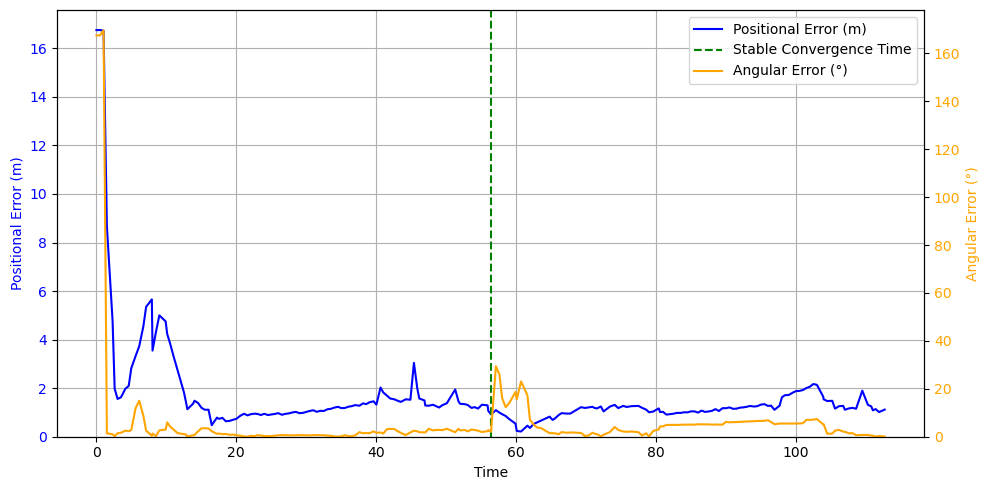

Convergence invalidated at 55.10s due to divergence.
Convergence invalidated at 55.10s due to divergence.
 — Stable convergence time: 58.07s
 — Mean positional error after convergence: 1.017 m
 — Mean angular error after convergence: 3.42°



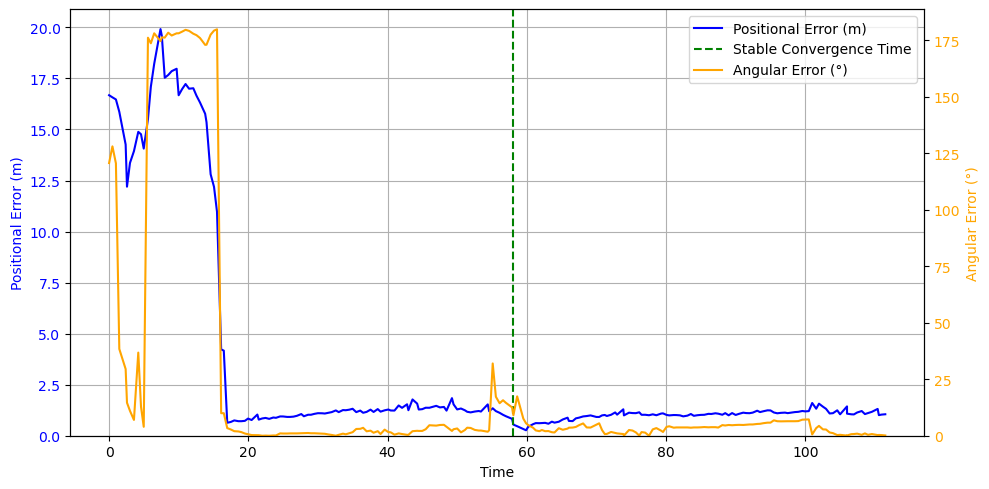

 — Stable convergence time: 18.49s
 — Mean positional error after convergence: 0.985 m
 — Mean angular error after convergence: 2.82°



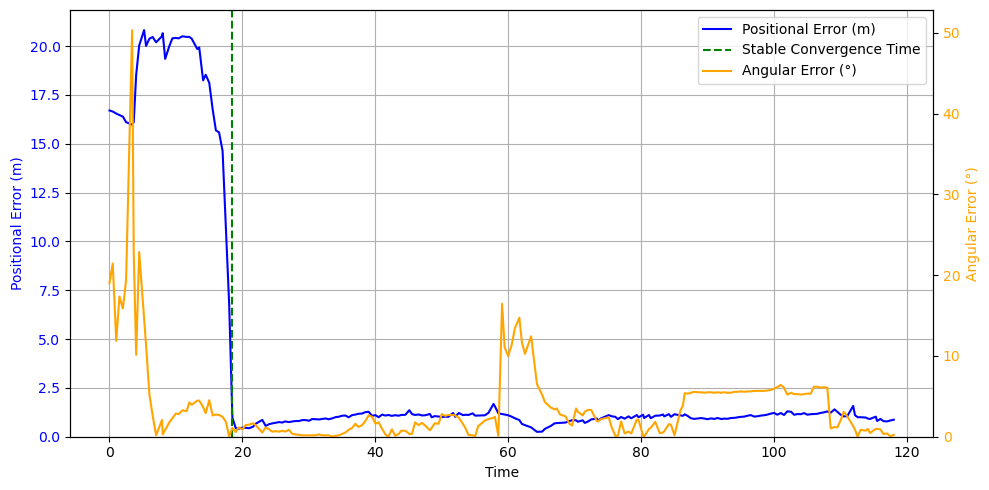

Convergence invalidated at 47.44s due to divergence.
Convergence invalidated at 47.44s due to divergence.
 — Stable convergence time: 59.59s
 — Mean positional error after convergence: 1.144 m
 — Mean angular error after convergence: 2.78°



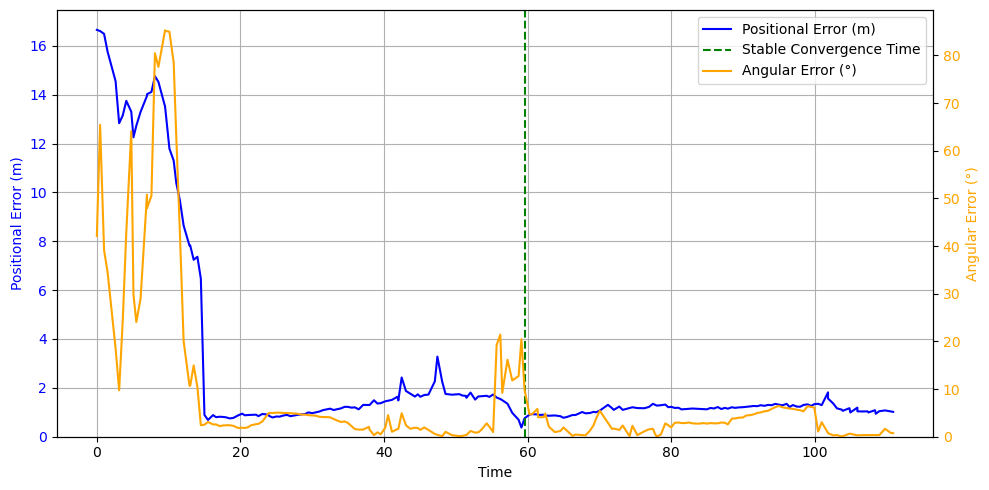

 — Stable convergence time: 16.52s
 — Mean positional error after convergence: 1.089 m
 — Mean angular error after convergence: 3.01°



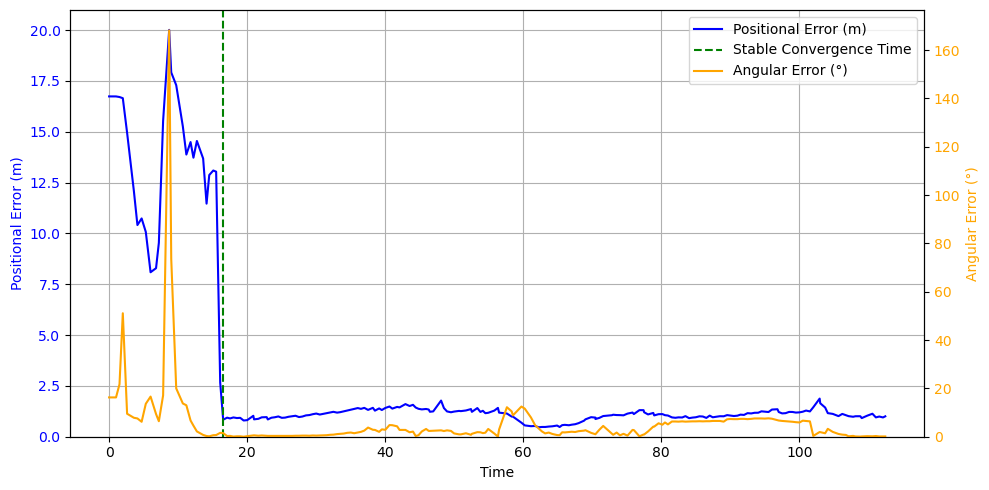

 — Stable convergence time: 16.99s
 — Mean positional error after convergence: 1.111 m
 — Mean angular error after convergence: 2.74°



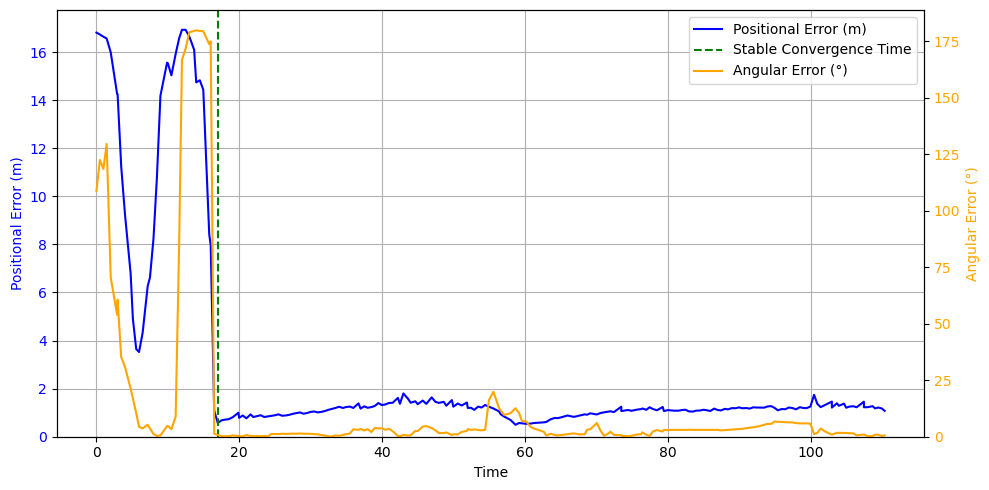

Convergence invalidated at 47.76s due to divergence.
Convergence invalidated at 47.76s due to divergence.
 — Stable convergence time: 56.07s
 — Mean positional error after convergence: 0.918 m
 — Mean angular error after convergence: 3.43°



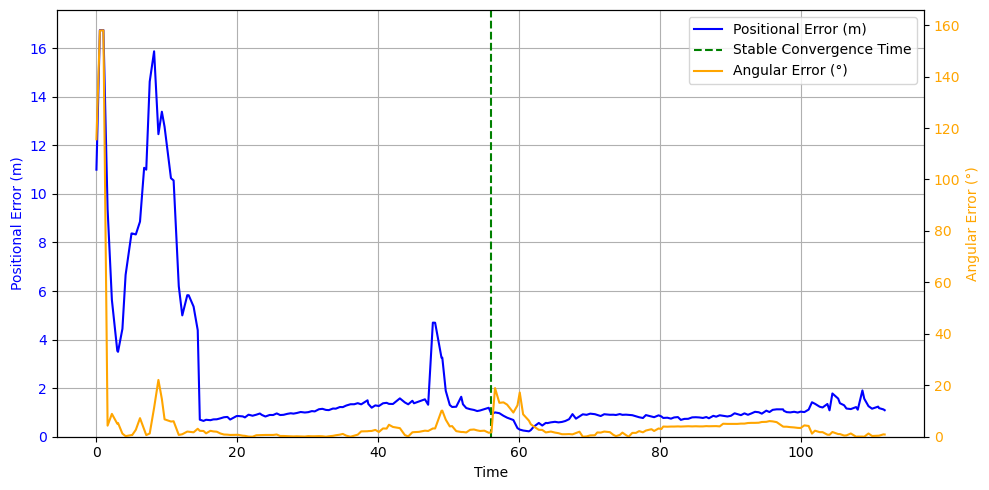

 — Stable convergence time: 13.99s
 — Mean positional error after convergence: 0.858 m
 — Mean angular error after convergence: 2.58°



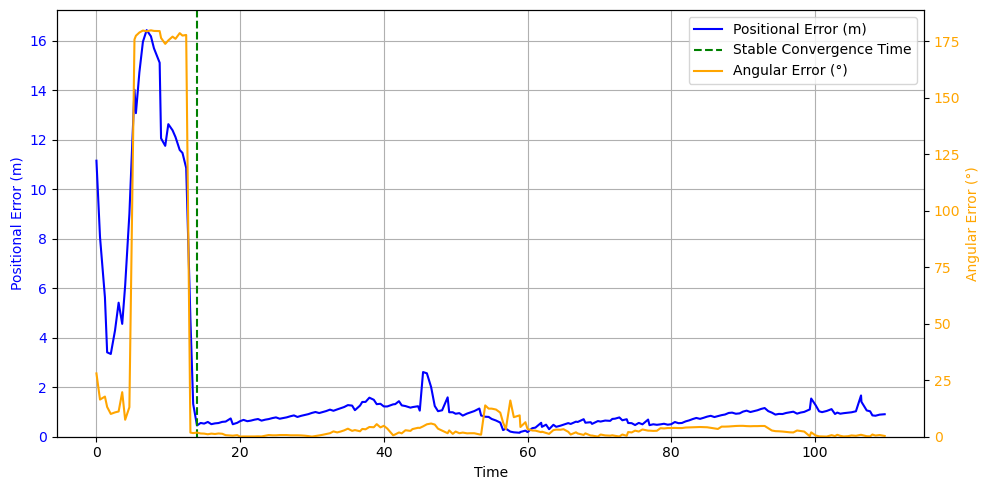

Convergence invalidated at 8.61s due to divergence.
Convergence invalidated at 56.90s due to divergence.
Convergence invalidated at 8.61s due to divergence.
Convergence invalidated at 56.90s due to divergence.
 — Stable convergence time: 61.11s
 — Mean positional error after convergence: 0.856 m
 — Mean angular error after convergence: 2.50°



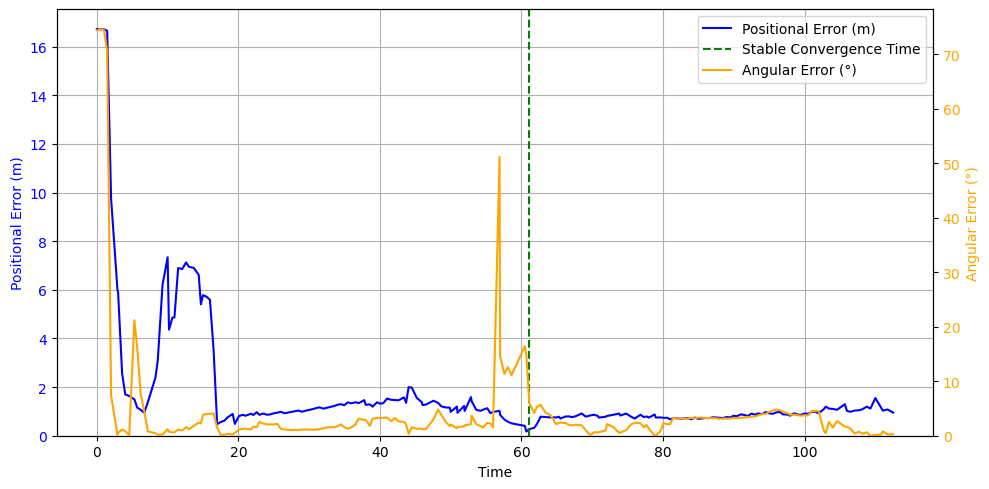

Convergence invalidated at 45.15s due to divergence.
Convergence invalidated at 45.15s due to divergence.
 — Stable convergence time: 51.51s
 — Mean positional error after convergence: 1.070 m
 — Mean angular error after convergence: 3.82°



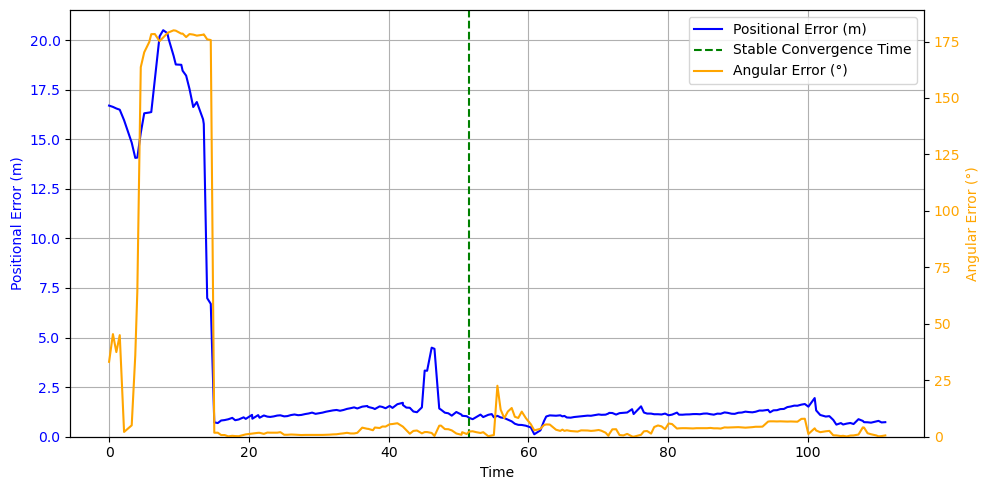

Convergence invalidated at 41.10s due to divergence.
Convergence invalidated at 41.10s due to divergence.
 — Stable convergence time: 57.96s
 — Mean positional error after convergence: 1.047 m
 — Mean angular error after convergence: 3.41°



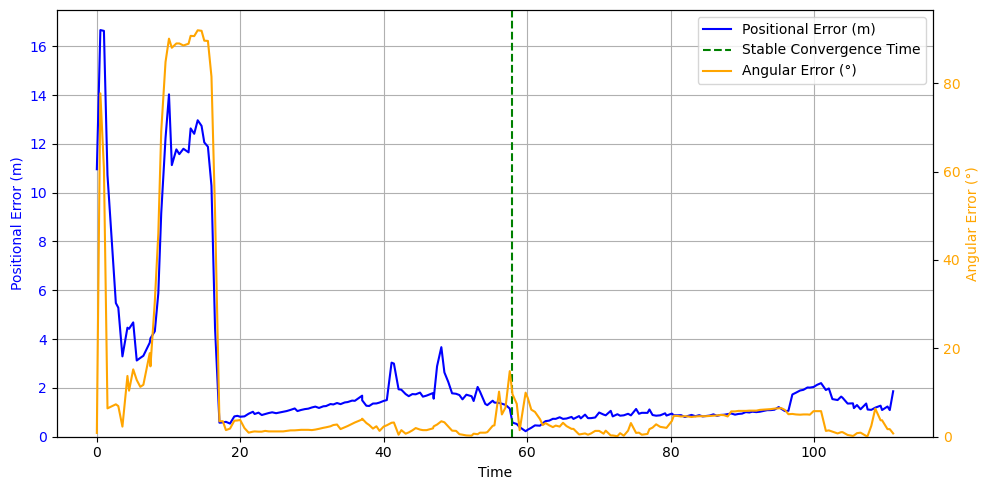

Convergence invalidated at 47.99s due to divergence.
Convergence invalidated at 47.99s due to divergence.
 — Stable convergence time: 57.51s
 — Mean positional error after convergence: 1.034 m
 — Mean angular error after convergence: 4.30°



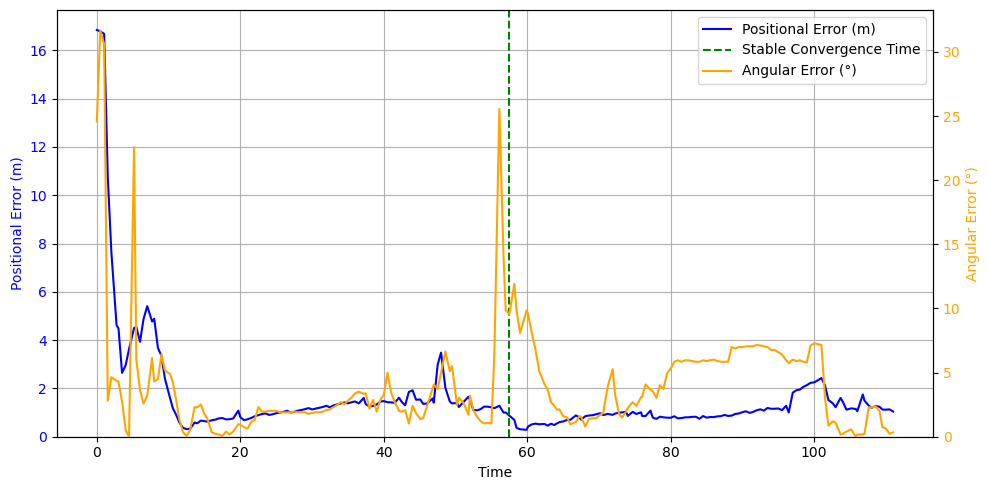

Average convergence time: 40.95 s
Average post convergence positional error : 1.02 m
Average post convergence angular error: 3.18 deg
Convergence rate : 100.00% 
#### BEST TRIAL ####


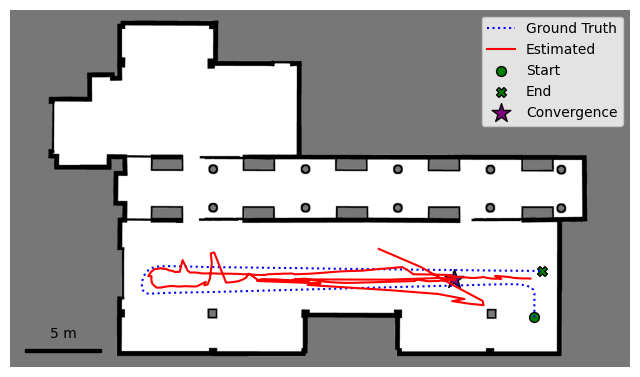

 — Stable convergence time: 13.99s
 — Mean positional error after convergence: 0.858 m
 — Mean angular error after convergence: 2.58°



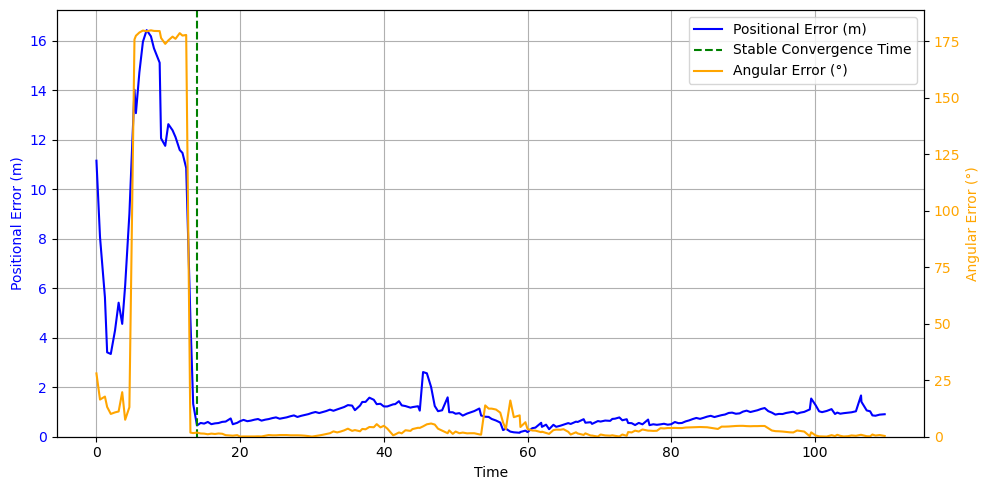

#### WORST TRIAL ####
Convergence invalidated at 8.61s due to divergence.
Convergence invalidated at 56.90s due to divergence.


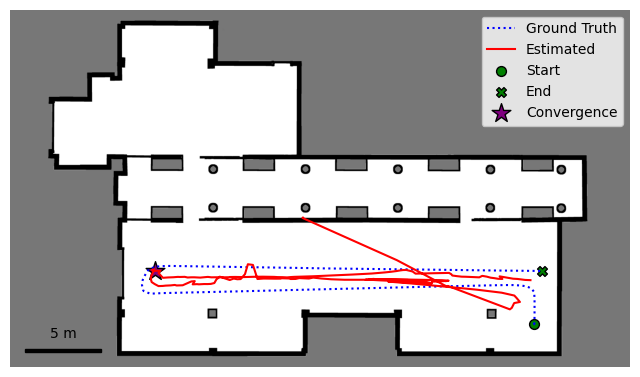

Convergence invalidated at 8.61s due to divergence.
Convergence invalidated at 56.90s due to divergence.
 — Stable convergence time: 61.11s
 — Mean positional error after convergence: 0.856 m
 — Mean angular error after convergence: 2.50°



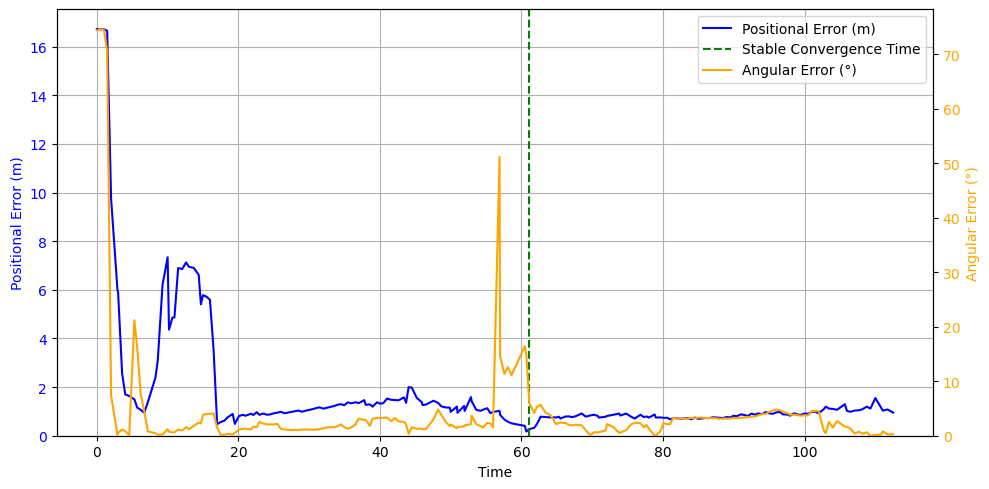

In [52]:
import os 

root = "/home/joao/dev/PF_graphs/MM_FAISS/20000_particles/Area_A_loop/"
trials = os.listdir(root)

trial_data = []
not_converged = 0

for trial in trials:
    df = load_csv(root + trial)
    convergence_time, mean_pos_error, mean_ang_error = get_stable_convergence(df)
    if convergence_time == -1:
        not_converged += 1
    else:
        trial_data.append((convergence_time, mean_pos_error, mean_ang_error, df))
    plot_errors(df)

if len(trial_data) == 0:
    raise SystemExit("No convergences!")

avg_convergence_time = sum([t[0] for t in trial_data]) / len(trial_data)
avg_pos_error = sum([t[1] for t in trial_data]) / len(trial_data)
avg_ang_error = sum([t[2] for t in trial_data]) / len(trial_data)
success_rate = 1 - not_converged / len(trials)

print(f"Average convergence time: {avg_convergence_time:.2f} s")
print(f"Average post convergence positional error : {avg_pos_error:.2f} m")
print(f"Average post convergence angular error: {avg_ang_error:.2f} deg")
print(f"Convergence rate : {success_rate*100:.2f}% ")

best_trial = min(trial_data, key = lambda x: x[0])[3]
worst_trial = max(trial_data, key = lambda x: x[0])[3]

print("#### BEST TRIAL ####")
plot_both_trajectories(best_trial)
plot_errors(best_trial)

print("#### WORST TRIAL ####")
plot_both_trajectories(worst_trial)
plot_errors(worst_trial)